workshop
 RIHEL FATMA ZOHRA
 Génie des pr



**RIHEL FATMA ZOHRA ** Génie des procédes (Organique )

Saving AAPL.csv to AAPL (2).csv
Dataset chargé avec succès !
Dimensions : (184, 7)
Colonnes : Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')
        Date        Open        High         Low       Close   Adj Close  \
0 2014-09-29  100.589996  100.690002   98.040001   99.620003   93.514290   
1 2014-10-06   99.949997  102.379997   98.309998  100.730003   94.556244   
2 2014-10-13  101.330002  101.779999   95.180000   97.669998   91.683792   
3 2014-10-20   98.320000  105.489998   98.220001  105.220001   98.771042   
4 2014-10-27  104.849998  108.040001  104.699997  108.000000  101.380676   

      Volume  
0  142718700  
1  280258200  
2  358539800  
3  358532900  
4  220230600  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       184 non-null    datetime64[ns]
 1   Open       184 non-nul

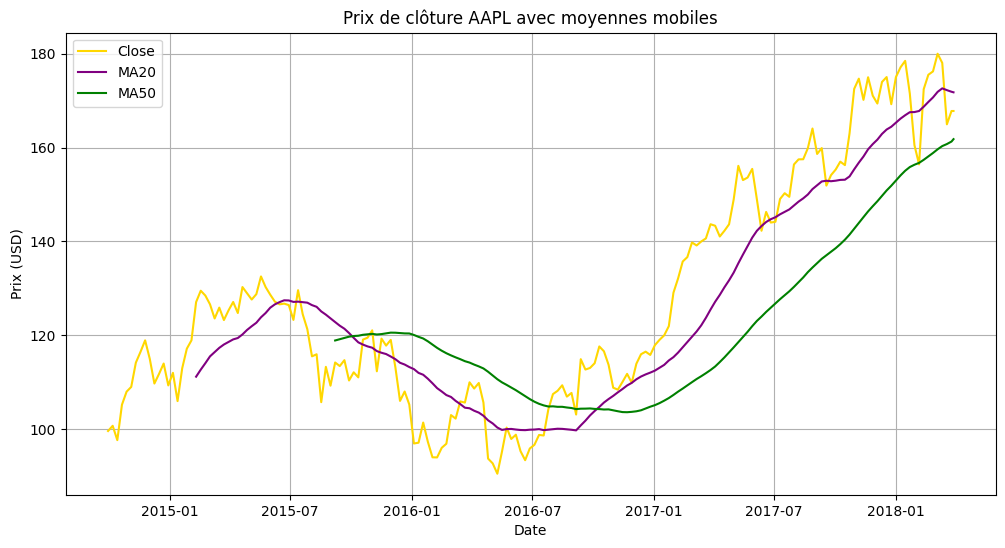

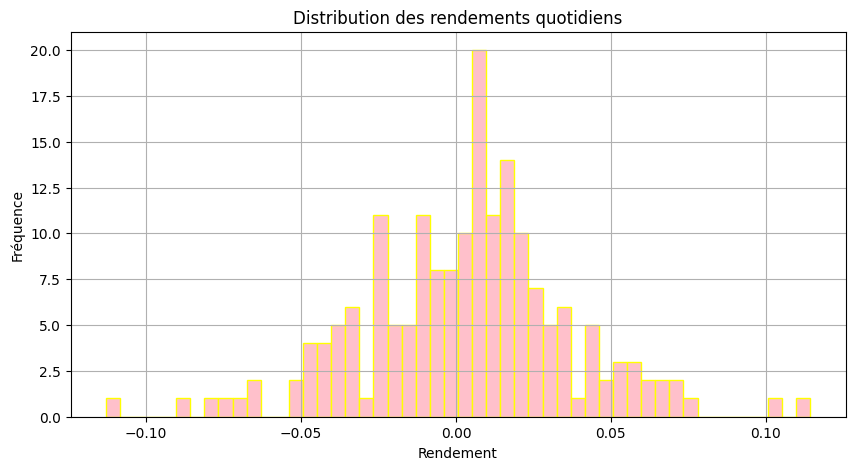

In [14]:
#Importer le fichier CSV depuis Google Colab
import pandas as pd
from google.colab import files
uploaded = files.upload()

# Lire le fichier CSV
df = pd.read_csv('AAPL.csv', parse_dates=['Date'])


#Vérification que le dataset est chargé correctement
print("Dataset chargé avec succès !")
print("Dimensions :", df.shape)
print("Colonnes :", df.columns)
print(df.head())

#Importer les bibliothèques
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Manipulations de données avec Pandas et NumPy

print(df.info())


print(df.describe())

# Créer une colonne
df['Daily_Return'] = df['Close'].pct_change()

# Moyenne mobile sur 20 jours et 50 jours pour le prix de clôture
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

# Moyenne et écart-type du prix de clôture avec NumPy
mean_close = np.mean(df['Close'])
std_close = np.std(df['Close'])
print("Prix moyen de clôture :", round(mean_close, 2))
print("Écart-type du prix de clôture :", round(std_close, 2))

# Volume moyen
avg_volume = np.mean(df['Volume'])
print("Volume moyen :", int(avg_volume))


# Visualisations avec Matplotlib

#  Prix de clôture avec moyennes mobiles
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Close', color='Gold')
plt.plot(df['Date'], df['MA20'], label='MA20', color='Purple')
plt.plot(df['Date'], df['MA50'], label='MA50', color='green')
plt.title("Prix de clôture AAPL avec moyennes mobiles")
plt.xlabel("Date")
plt.ylabel("Prix (USD)")
plt.legend()
plt.grid(True)
plt.show()

#  Histogramme des rendements quotidiens
plt.figure(figsize=(10,5))
plt.hist(df['Daily_Return'].dropna(), bins=50, color='Pink', edgecolor='Yellow')
plt.title("Distribution des rendements quotidiens")
plt.xlabel("Rendement")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()


# Visualisations interactives avec Plotly
# Graphique interactif du prix de clôture
fig = px.line(df, x='Date', y='Close', title='Prix de clôture AAPL', labels={'Close':'Prix (USD)'})
fig.show()

#  Graphique en chandelier (candlestick)
fig = go.Figure(data=[go.Candlestick(x=df['Date'],
                                     open=df['Open'], high=df['High'],
                                     low=df['Low'], close=df['Close'])])
fig.update_layout(title='Chandeliers AAPL', xaxis_title='Date', yaxis_title='Prix (USD)')
fig.show()

#  Histogramme interactif des rendements
fig = px.histogram(df, x='Daily_Return', nbins=50, title="Distribution des rendements quotidiens",
                   labels={'Daily_Return':'Rendement'})
fig.show()
